In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from source import tools as tls

In [4]:
path = "./output/TRAPPIST-1b_EH3/TRAPPIST-1b_EH3_tp.dat"
press, temp, cpress0, ctemp0, cpress1, ctemp1, cpress2, ctemp2, cpress3, ctemp3 = tls.read_helios_tp(path)

In [6]:
press

[0.5,
 0.448187,
 0.36011299999999996,
 0.289346,
 0.232486,
 0.1868,
 0.150091,
 0.120596,
 0.09689769999999999,
 0.0778561,
 0.0625564,
 0.050263300000000004,
 0.0403859,
 0.032449599999999995,
 0.0260729,
 0.0209492,
 0.0168324,
 0.0135246,
 0.010866899999999999,
 0.00873141,
 0.0070155799999999996,
 0.00563693,
 0.0045292,
 0.00363916,
 0.00292402,
 0.0023494099999999997,
 0.0018877199999999998,
 0.00151676,
 0.0012187,
 0.0009792099999999999,
 0.000786783,
 0.0006321699999999999,
 0.0005079409999999999,
 0.000408124,
 0.000327923,
 0.000263482,
 0.000211704,
 0.000170102,
 0.000136675,
 0.000109816,
 8.82361e-05,
 7.089660000000001e-05,
 5.696459999999999e-05,
 4.57703e-05,
 3.67759e-05,
 2.9548999999999998e-05,
 2.3742199999999998e-05,
 1.90766e-05,
 1.53278e-05,
 1.23157e-05,
 9.8955e-06,
 7.95091e-06,
 6.38846e-06,
 5.13305e-06,
 4.12434e-06,
 3.31386e-06,
 2.66264e-06,
 2.1394000000000002e-06,
 1.7189799999999998e-06,
 1.38118e-06,
 1.1097600000000001e-06,
 8.916789999999999e-

In [36]:
#output tp profile for fastchem
fc_path = "./output/TRAPPIST-1f_EH3/chemistry/tp.dat"
arr = np.column_stack((np.array(press), np.array(temp)))
np.savetxt(fc_path, arr, header='pressure(bar) temperature(K)', fmt='%.6e %.6f', comments='')
print(f"Wrote {arr.shape[0]} rows to {fc_path}")

Wrote 72 rows to ./output/TRAPPIST-1f_EH3/chemistry/tp.dat


In [5]:
#get condensates from dedicated FastChem output
condensates = pd.read_csv("output/TRAPPIST-1b_EH3/chemistry/condensates.dat", sep="\\s+")
condensates.rename(columns={'#p(bar)': 'p(bar)'}, inplace=True)

In [6]:
# Rename columns without '(' character to have '_frac' suffix
condensates.rename(columns=lambda x: x + '_frac' if '(' not in x else x, inplace=True)

In [7]:
# Get columns that have '(s)', '(l)', or '(s,l)' in the name
cond_columns = [col for col in condensates.columns if '(s)' in col or '(l)' in col or '(s,l)' in col]

In [8]:
# find zero->nonzero transitions for condensate columns (do not count the first row as a transition)
transitions = []
for col in cond_columns:
    mask = condensates[col] > 0
    # treat the "previous" value for the first row as True so a True at index 0 is NOT counted as a rise
    rises = (~mask.shift(1, fill_value=True)) & mask
    if rises.any():
        for idx in condensates.index[rises]:
            transitions.append({
                'col': col,
                'row': int(idx),
                'p(bar)': condensates.at[idx, 'p(bar)'],
                'T(K)': condensates.at[idx, 'T(K)'],
                'value': condensates.at[idx, col]
            })

if transitions:
    res = pd.DataFrame(transitions).sort_values(['col','row']).reset_index(drop=True)
    print(f"Found {len(res)} zero->nonzero transitions (excluding first datapoint):")
    print(res)
else:
    print("No zero->nonzero transitions found in cond_columns.")

Found 1 zero->nonzero transitions (excluding first datapoint):
    col  row    p(bar)     T(K)         value
0  C(s)   57  0.000002  366.323  4.409215e+10


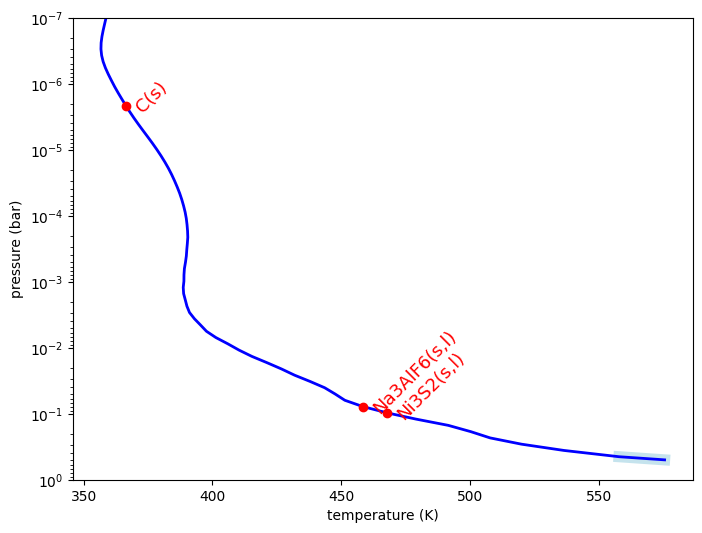

In [71]:
color='blue'
shade='lightblue'
label= 'TRAPPIST-1b EH3 TP Profile'
width=2
style='-'
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(ctemp0, cpress0, color=shade,linewidth=8, alpha=0.7)
ax.plot(ctemp1, cpress1, color=shade,linewidth=8, alpha=0.7)
ax.plot(ctemp2, cpress2, color=shade,linewidth=8, alpha=0.7)
ax.plot(ctemp3, cpress3, color=shade,linewidth=8, alpha=0.7)

line, = ax.plot(temp, press, color=color, linewidth=width, linestyle=style, alpha=1, label=label)
ax.set(ylim=[1e0, 1e-7], yscale='log', xlabel=r'temperature (K)', ylabel=r'pressure (bar)')

#annotate condensate formation points
for index, row in res.iterrows():
    ax.plot(row['T(K)'], row['p(bar)'], marker='o', color='red')
    ax.annotate(row['col'], xy=(row['T(K)'], row['p(bar)']), xytext=(5, -5), textcoords='offset points', color='red', fontsize=13, rotation=45)

In [2]:
import os

#print fastchem tp for each planet
names = ['TRAPPIST-1b', 'TRAPPIST-1c', 'TRAPPIST-1d', 'TRAPPIST-1e', 'TRAPPIST-1f', 'TRAPPIST-1g', 'TRAPPIST-1h']


In [ ]:
for name in names:
    path = f"./output/{name}_EH3/{name}_EH3_tp.dat"
    press, temp, cpress0, ctemp0, cpress1, ctemp1, cpress2, ctemp2, cpress3, ctemp3 = tls.read_helios_tp(path)

    #output tp profile for fastchem
    fc_path = f"./output/{name}_EH3/chemistry/tp.dat"
    fc_dir = os.path.dirname(fc_path)
    if not os.path.exists(fc_dir):
        os.makedirs(fc_dir, exist_ok=True)
    arr = np.column_stack((np.array(press), np.array(temp)))
    np.savetxt(fc_path, arr, header='pressure(bar) temperature(K)', fmt='%.6e %.6f', comments='')
    print(f"Wrote {arr.shape[0]} rows to {fc_path}")

In [11]:
from pathlib import Path

src_dir_name = "output/TRAPPIST-1b_EH3/chemistry"
src_path = Path(f"./{src_dir_name}/config.dat")
if not src_path.exists():
    raise FileNotFoundError(f"Source config file not found: {src_path}")

src_text = src_path.read_text()

# `names` is defined earlier in the notebook; replace all exact occurrences of "TRAPPIST-1b"
for display_name in names:
    tgt_dir = Path(f"./output/{display_name}_EH3/chemistry")
    tgt_path = tgt_dir / "config.dat"
    new_text = src_text.replace("TRAPPIST-1b", display_name)
    tgt_path.write_text(new_text)
    print(f"Wrote: {tgt_path}")


Wrote: output/TRAPPIST-1c_EH3/chemistry/config.dat
Wrote: output/TRAPPIST-1d_EH3/chemistry/config.dat
Wrote: output/TRAPPIST-1e_EH3/chemistry/config.dat
Wrote: output/TRAPPIST-1f_EH3/chemistry/config.dat
Wrote: output/TRAPPIST-1g_EH3/chemistry/config.dat
Wrote: output/TRAPPIST-1h_EH3/chemistry/config.dat


TRAPPIST-1b: Found 1 zero->nonzero transitions (excluding first datapoint):
    col  row    p(bar)     T(K)         value
0  C(s)   57  0.000002  366.323  4.409215e+10
TRAPPIST-1c: No zero->nonzero transitions found in cond_columns.
TRAPPIST-1d: Found 2 zero->nonzero transitions (excluding first datapoint):
            col  row    p(bar)     T(K)         value
0  Na3AlF6(s,l)    2  0.360113  459.685  1.980272e+14
1    Ni3S2(s,l)    1  0.448187  475.327  1.667129e+17
TRAPPIST-1e: No zero->nonzero transitions found in cond_columns.
TRAPPIST-1f: No zero->nonzero transitions found in cond_columns.
TRAPPIST-1g: No zero->nonzero transitions found in cond_columns.
TRAPPIST-1h: No zero->nonzero transitions found in cond_columns.


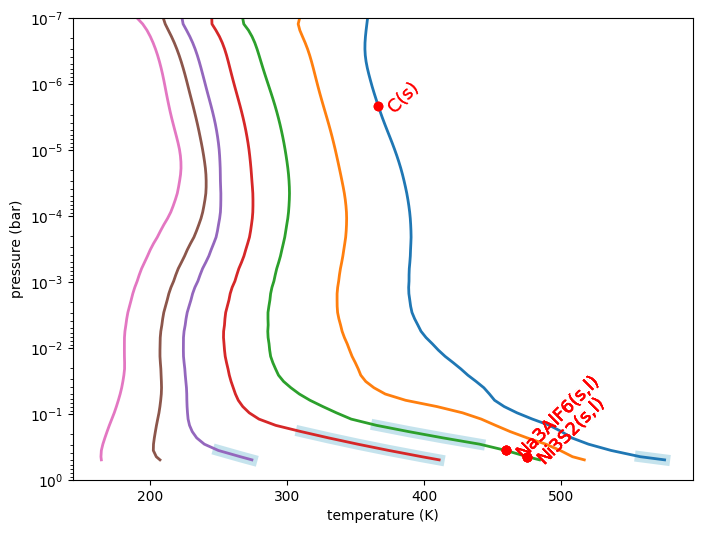

In [14]:
fig, ax = plt.subplots(figsize=(8,6))

#read all the condensate files and calculate formation points
for i, name in enumerate(names):
    cond_path = f"./output/{name}_EH3/chemistry/condensates.dat"
    condensates = pd.read_csv(cond_path, sep="\\s+")
    condensates.rename(columns={'#p(bar)': 'p(bar)'}, inplace=True)

    # Rename columns without '(' character to have '_frac' suffix
    condensates.rename(columns=lambda x: x + '_frac' if '(' not in x else x, inplace=True)

    # Get columns that have '(s)', '(l)', or '(s,l)' in the name
    cond_columns = [col for col in condensates.columns if '(s)' in col or '(l)' in col or '(s,l)' in col]

    # find zero->nonzero transitions for condensate columns (do not count the first row as a transition)
    transitions = []
    for col in cond_columns:
        mask = condensates[col] > 0
        # treat the "previous" value for the first row as True so a True at index 0 is NOT counted as a rise
        rises = (~mask.shift(1, fill_value=True)) & mask
        if rises.any():
            for idx in condensates.index[rises]:
                transitions.append({
                    'col': col,
                    'row': int(idx),
                    'p(bar)': condensates.at[idx, 'p(bar)'],
                    'T(K)': condensates.at[idx, 'T(K)'],
                    'value': condensates.at[idx, col]
                })

    if transitions:
        res = pd.DataFrame(transitions).sort_values(['col','row']).reset_index(drop=True)
        print(f"{name}: Found {len(res)} zero->nonzero transitions (excluding first datapoint):")
        print(res)
    else:
        print(f"{name}: No zero->nonzero transitions found in cond_columns.")

    #plot tp profile with condensate points
    color=f'C{i}'
    shade='lightblue'
    label= f'{name} EH3 TP Profile'
    width=2
    style='-'
    tp_path = f"./output/{name}_EH3/{name}_EH3_tp.dat"
    press, temp, cpress0, ctemp0, cpress1, ctemp1, cpress2, ctemp2, cpress3, ctemp3 = tls.read_helios_tp(tp_path)

    ax.plot(ctemp0, cpress0, color=shade,linewidth=8, alpha=0.7)
    ax.plot(ctemp1, cpress1, color=shade,linewidth=8, alpha=0.7)
    ax.plot(ctemp2, cpress2, color=shade,linewidth=8, alpha=0.7)
    ax.plot(ctemp3, cpress3, color=shade,linewidth=8, alpha=0.7)

    ax.plot(temp, press, color=color, linewidth=width, linestyle=style, alpha=1, label=label)
    ax.set(ylim=[1e0, 1e-7], yscale='log', xlabel=r'temperature (K)', ylabel=r'pressure (bar)')
    #annotate condensate formation points
    for index, row in res.iterrows():
        ax.plot(row['T(K)'], row['p(bar)'], marker='o', color='red')
        ax.annotate(row['col'], xy=(row['T(K)'], row['p(bar)']), xytext=(5, -5), textcoords='offset points', color='red', fontsize=13, rotation=45)


In [6]:
from pathlib import Path
src_dir_name = "output/TRAPPIST-1b_asplund_m3/chemistry"
src_path = Path(f"./{src_dir_name}/config.dat")
if not src_path.exists():
    raise FileNotFoundError(f"Source config file not found: {src_path}")

src_text = src_path.read_text()

for name in names:
    path = f"./output/{name}_asplund_m3/{name}_asplund_m3_tp.dat"
    press, temp, cpress0, ctemp0, cpress1, ctemp1, cpress2, ctemp2, cpress3, ctemp3 = tls.read_helios_tp(path)

    #output tp profile for fastchem
    fc_path = f"./output/{name}_asplund_m3/chemistry/tp.dat"
    fc_dir = os.path.dirname(fc_path)
    if not os.path.exists(fc_dir):
        os.makedirs(fc_dir, exist_ok=True)
    arr = np.column_stack((np.array(press), np.array(temp)))
    np.savetxt(fc_path, arr, header='pressure(bar) temperature(K)', fmt='%.6e %.6f', comments='')
    print(f"Wrote {arr.shape[0]} rows to {fc_path}")
    from pathlib import Path

    tgt_dir = Path(f"./output/{name}_asplund_m3/chemistry")
    tgt_path = tgt_dir / "config.dat"
    new_text = src_text.replace("TRAPPIST-1b", name)
    tgt_path.write_text(new_text)
    print(f"Wrote: {tgt_path}")

Wrote 72 rows to ./output/TRAPPIST-1b_asplund_m3/chemistry/tp.dat
Wrote: output/TRAPPIST-1b_asplund_m3/chemistry/config.dat
Wrote 72 rows to ./output/TRAPPIST-1c_asplund_m3/chemistry/tp.dat
Wrote: output/TRAPPIST-1c_asplund_m3/chemistry/config.dat
Wrote 72 rows to ./output/TRAPPIST-1d_asplund_m3/chemistry/tp.dat
Wrote: output/TRAPPIST-1d_asplund_m3/chemistry/config.dat
Wrote 72 rows to ./output/TRAPPIST-1e_asplund_m3/chemistry/tp.dat
Wrote: output/TRAPPIST-1e_asplund_m3/chemistry/config.dat
Wrote 72 rows to ./output/TRAPPIST-1f_asplund_m3/chemistry/tp.dat
Wrote: output/TRAPPIST-1f_asplund_m3/chemistry/config.dat
Wrote 72 rows to ./output/TRAPPIST-1g_asplund_m3/chemistry/tp.dat
Wrote: output/TRAPPIST-1g_asplund_m3/chemistry/config.dat
Wrote 72 rows to ./output/TRAPPIST-1h_asplund_m3/chemistry/tp.dat
Wrote: output/TRAPPIST-1h_asplund_m3/chemistry/config.dat


In [7]:
#run all the fastchem instances for asplund_m3
for name in names:
    os.system(f"~/FastChem/fastchem output/{name}_asplund_m3/chemistry/config.dat")


FastChem initialisation summary:
  number of species: 712    elements: 28    molecules: 495    condensates: 189

temperature-pressure profile read in from file:
  0	0.5	886.542
  1	0.448187	860.006
  2	0.360113	807.891
  3	0.289346	758.934
  4	0.232486	712.944
  5	0.1868	669.74
  6	0.150091	629.155
  7	0.120596	591.029
  8	0.0968977	555.214
  9	0.0778561	521.864
  10	0.0625564	501.454
  11	0.0502633	487.654
  12	0.0403859	477.663
  13	0.0324496	469.711
  14	0.0260729	463.243
  15	0.0209492	457.892
  16	0.0168324	452.982
  17	0.0135246	448.398
  18	0.0108669	444.409
  19	0.00873141	440.989
  20	0.00701558	437.912
  21	0.00563693	435.65
  22	0.0045292	434.345
  23	0.00363916	433.309
  24	0.00292402	432.855
  25	0.00234941	433.26
  26	0.00188772	433.961
  27	0.00151676	434.707
  28	0.0012187	436.021
  29	0.00097921	437.839
  30	0.000786783	439.331
  31	0.00063217	441.027
  32	0.000507941	443.088
  33	0.000408124	444.915
  34	0.000327923	446.377
  35	0.000263482	447.957
  36	0.000211704	4

TRAPPIST-1b: Found 15 zero->nonzero transitions (excluding first datapoint):
             col  row        p(bar)     T(K)         value
0     Al2O3(s,l)    3  2.893460e-01  758.934  1.367572e+03
1     Al2O3(s,l)   39  1.098160e-04  452.634  1.031071e-07
2     Al2SiO5(s)   64  4.625360e-07  424.071  4.990231e-12
3           C(s)    7  1.205960e-01  591.029  8.401322e+14
4      CaF2(s,l)    5  1.868000e-01  669.740  3.602241e-01
5      CaTiO3(s)    4  2.324860e-01  712.944  1.132214e+00
6        Cu(s,l)   15  2.094920e-02  457.892  1.314873e+01
7       FeS(s,l)   60  1.109760e-06  431.567  7.060570e-06
8       KCl(s,l)    2  3.601130e-01  807.891  2.580773e+12
9    MgTiO3(s,l)    1  4.481870e-01  860.006  1.222383e-03
10        MnS(s)   71  1.000000e-07  396.987  7.120261e-32
11  Na3AlF6(s,l)   10  6.255640e-02  501.454  1.544474e+01
12    Ni3S2(s,l)    2  3.601130e-01  807.891  8.372731e+05
13    Ni3S2(s,l)   55  3.313860e-06  440.802  7.588216e-13
14     TiO2(s,l)    2  3.601130e-01  8

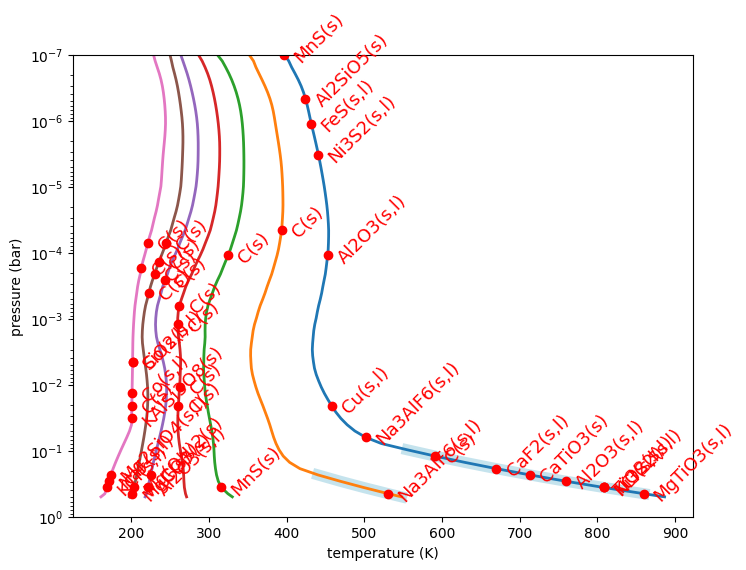

In [8]:
fig, ax = plt.subplots(figsize=(8,6))

#read all the condensate files and calculate formation points
for i, name in enumerate(names):
    cond_path = f"./output/{name}_asplund_m3/chemistry/condensates.dat"
    condensates = pd.read_csv(cond_path, sep="\\s+")
    condensates.rename(columns={'#p(bar)': 'p(bar)'}, inplace=True)

    # Rename columns without '(' character to have '_frac' suffix
    condensates.rename(columns=lambda x: x + '_frac' if '(' not in x else x, inplace=True)

    # Get columns that have '(s)', '(l)', or '(s,l)' in the name
    cond_columns = [col for col in condensates.columns if '(s)' in col or '(l)' in col or '(s,l)' in col]

    # find zero->nonzero transitions for condensate columns (do not count the first row as a transition)
    transitions = []
    for col in cond_columns:
        mask = condensates[col] > 0
        # treat the "previous" value for the first row as True so a True at index 0 is NOT counted as a rise
        rises = (~mask.shift(1, fill_value=True)) & mask
        if rises.any():
            for idx in condensates.index[rises]:
                transitions.append({
                    'col': col,
                    'row': int(idx),
                    'p(bar)': condensates.at[idx, 'p(bar)'],
                    'T(K)': condensates.at[idx, 'T(K)'],
                    'value': condensates.at[idx, col]
                })

    if transitions:
        res = pd.DataFrame(transitions).sort_values(['col','row']).reset_index(drop=True)
        print(f"{name}: Found {len(res)} zero->nonzero transitions (excluding first datapoint):")
        print(res)
    else:
        print(f"{name}: No zero->nonzero transitions found in cond_columns.")

    #plot tp profile with condensate points
    color=f'C{i}'
    shade='lightblue'
    label= f'{name} asplund_m3 TP Profile'
    width=2
    style='-'
    tp_path = f"./output/{name}_asplund_m3/{name}_asplund_m3_tp.dat"
    press, temp, cpress0, ctemp0, cpress1, ctemp1, cpress2, ctemp2, cpress3, ctemp3 = tls.read_helios_tp(tp_path)

    ax.plot(ctemp0, cpress0, color=shade,linewidth=8, alpha=0.7)
    ax.plot(ctemp1, cpress1, color=shade,linewidth=8, alpha=0.7)
    ax.plot(ctemp2, cpress2, color=shade,linewidth=8, alpha=0.7)
    ax.plot(ctemp3, cpress3, color=shade,linewidth=8, alpha=0.7)

    ax.plot(temp, press, color=color, linewidth=width, linestyle=style, alpha=1, label=label)
    ax.set(ylim=[1e0, 1e-7], yscale='log', xlabel=r'temperature (K)', ylabel=r'pressure (bar)')
    #annotate condensate formation points
    for index, row in res.iterrows():
        ax.plot(row['T(K)'], row['p(bar)'], marker='o', color='red')
        ax.annotate(row['col'], xy=(row['T(K)'], row['p(bar)']), xytext=(5, -5), textcoords='offset points', color='red', fontsize=13, rotation=45)
